In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
from torchvision.models import densenet121
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from PIL import Image
from scipy.ndimage import label
import timm
from tqdm import tqdm


In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cuda


In [3]:
TILE_IMAGE_DIR = "/home/kishore/Downloads/na_sd_da_f_g_fafd_l.v1i.coco/train"
FEATURES_PATH = "data/features/fusion/train_features.npz"
MASK_MODEL_PATH = "models/mask_kcnn/mask_kcnn_step1.pth"


In [4]:
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor


In [5]:
def load_mask_model():
    m = maskrcnn_resnet50_fpn(weights=None)

    m.roi_heads.box_predictor = FastRCNNPredictor(
        m.roi_heads.box_predictor.cls_score.in_features, 3
    )
    m.roi_heads.mask_predictor = MaskRCNNPredictor(
        m.roi_heads.mask_predictor.conv5_mask.in_channels, 256, 3
    )

    m.load_state_dict(torch.load(MASK_MODEL_PATH, map_location=DEVICE))
    return m.to(DEVICE).eval()

mask_model = load_mask_model()
print("Mask-K-CNN loaded")


Mask-K-CNN loaded


In [6]:
def steatosis_grade(pct):
    if pct < 0.05: return 0
    if pct < 0.33: return 1
    if pct < 0.66: return 2
    return 3


In [7]:
def extract_tile_features(image_path):
    img = Image.open(image_path).convert("RGB")
    tensor = TF.to_tensor(img).to(DEVICE)
    H, W = img.size[1], img.size[0]

    with torch.no_grad():
        out = mask_model([tensor])[0]

    stea = np.zeros((H, W), dtype=bool)
    ball = np.zeros((H, W), dtype=bool)

    for m, l, s in zip(out["masks"], out["labels"], out["scores"]):
        if s < 0.5:
            continue
        mask = m.squeeze().cpu().numpy() > 0.5
        if l == 1:
            stea |= mask
        elif l == 2:
            ball |= mask

    stea_pct = float(stea.sum() / (H * W))
    _, balloon_cnt = label(ball)

    severity = steatosis_grade(stea_pct)
    activity = min(balloon_cnt, 2)
    risk = 1 if severity >= 2 else 0

    return {
        "image": np.array(img),
        "mask_steatosis": stea.astype(np.uint8),
        "mask_ballooning": ball.astype(np.uint8),
        "steatosis_pct": stea_pct,
        "ballooning_cnt": float(balloon_cnt),
        "severity": severity,
        "activity": activity,
        "risk": risk
    }


In [8]:
def build_fusion_npz(image_dir, out_file):
    records = []

    for fname in tqdm(os.listdir(image_dir)):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        path = os.path.join(image_dir, fname)
        if os.path.isdir(path):
            continue

        records.append(extract_tile_features(path))

    os.makedirs(os.path.dirname(out_file), exist_ok=True)
    np.savez_compressed(out_file, data=records)

build_fusion_npz(TILE_IMAGE_DIR, FEATURES_PATH)
print("Fusion features rebuilt")


100%|███████████████████████████████████████| 2479/2479 [01:08<00:00, 36.11it/s]


Fusion features rebuilt


In [9]:
class FusionDataset(Dataset):
    def __init__(self, npz_path):
        self.data = np.load(npz_path, allow_pickle=True)["data"]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        d = self.data[idx]

        img = torch.tensor(d["image"]).permute(2,0,1) / 255.0

        mask_stack = torch.stack([
            torch.tensor(d["mask_steatosis"]),
            torch.tensor(d["mask_ballooning"])
        ])

        vit_input = torch.cat([img, mask_stack], dim=0)
        vit_input = F.interpolate(
            vit_input.unsqueeze(0),
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        return (
            img.float(),
            vit_input.float(),
            torch.tensor(d["severity"], dtype=torch.long),
            torch.tensor(d["activity"], dtype=torch.long),
            torch.tensor(d["risk"], dtype=torch.float32),
            torch.tensor(d["steatosis_pct"], dtype=torch.float32),
            torch.tensor(d["ballooning_cnt"], dtype=torch.float32)
        )


In [10]:
dataset = FusionDataset(FEATURES_PATH)
img, vit, sev, act, risk, sp, bc = dataset[0]

print("DenseNet:", img.shape)   # [3,512,512]
print("ViT:", vit.shape)        # [5,224,224]
print("Stea %:", sp, "Ball cnt:", bc)


DenseNet: torch.Size([3, 512, 512])
ViT: torch.Size([5, 224, 224])
Stea %: tensor(0.) Ball cnt: tensor(15.)


In [11]:
class DenseNetViTFusion(nn.Module):
    def __init__(self):
        super().__init__()

        self.densenet = densenet121(pretrained=True)
        self.densenet.classifier = nn.Identity()

        self.vit = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            in_chans=5
        )
        self.vit.head = nn.Identity()

        self.fusion = nn.Sequential(
            nn.Linear(1024 + 768, 512),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.head_severity = nn.Linear(512, 4)
        self.head_activity = nn.Linear(512, 3)
        self.head_risk = nn.Linear(512, 1)
        self.head_stea_pct = nn.Linear(512, 1)
        self.head_ball_cnt = nn.Linear(512, 1)

    def forward(self, img, vit_in):
        if vit_in.shape[-1] != 224:
            vit_in = F.interpolate(vit_in, size=(224,224), mode="bilinear")

        f_d = self.densenet(img)
        f_v = self.vit(vit_in)
        f = self.fusion(torch.cat([f_d, f_v], dim=1))

        return (
            self.head_severity(f),
            self.head_activity(f),
            torch.sigmoid(self.head_risk(f)),
            torch.sigmoid(self.head_stea_pct(f)),
            F.relu(self.head_ball_cnt(f))
        )


In [12]:
loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=4)

model = DenseNetViTFusion().to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

loss_sev = nn.CrossEntropyLoss()
loss_act = nn.CrossEntropyLoss()
loss_risk = nn.BCELoss()


/home/kishore/majorproject/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kishore/majorproject/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    cs = ca = cr = total = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for img, vit, sev, act, risk, sp, bc in pbar:
        img = img.to(DEVICE)
        vit = vit.to(DEVICE)
        sev = sev.to(DEVICE)
        act = act.to(DEVICE)
        risk = risk.to(DEVICE)
        sp = sp.to(DEVICE)
        bc = bc.to(DEVICE)

        o_sev, o_act, o_risk, o_sp, o_bc = model(img, vit)

        loss = (
            loss_sev(o_sev, sev) +
            loss_act(o_act, act) +
            loss_risk(o_risk.squeeze(), risk) +
            0.5 * F.mse_loss(o_sp.squeeze(), sp) +
            0.2 * F.mse_loss(o_bc.squeeze(), bc)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        cs += (o_sev.argmax(1) == sev).sum().item()
        ca += (o_act.argmax(1) == act).sum().item()
        cr += ((o_risk.squeeze() > 0.5) == risk).sum().item()
        total += sev.size(0)

        pbar.set_postfix({
            "loss": f"{total_loss/total:.3f}",
            "sev": f"{cs/total:.2f}",
            "act": f"{ca/total:.2f}",
            "risk": f"{cr/total:.2f}",
        })

    print(
        f"Epoch {epoch+1} | "
        f"Loss={total_loss/len(loader):.4f} | "
        f"SevAcc={cs/total:.3f} | "
        f"ActAcc={ca/total:.3f} | "
        f"RiskAcc={cr/total:.3f}"
    )


Epoch 1/20: 100%|█| 310/310 [01:05<00:00,  4.76it/s, loss=0.279, sev=0.94, act=0


Epoch 1 | Loss=2.2287 | SevAcc=0.944 | ActAcc=0.988 | RiskAcc=0.986


Epoch 2/20: 100%|█| 310/310 [01:04<00:00,  4.77it/s, loss=0.098, sev=0.96, act=1


Epoch 2 | Loss=0.7847 | SevAcc=0.962 | ActAcc=0.998 | RiskAcc=0.991


Epoch 3/20: 100%|█| 310/310 [01:04<00:00,  4.77it/s, loss=0.062, sev=0.97, act=1


...

Epoch 18 | Loss=0.2360 | SevAcc=0.994 | ActAcc=1.000 | RiskAcc=0.999


Epoch 19/20: 100%|█| 310/310 [01:05<00:00,  4.77it/s, loss=0.020, sev=1.00, act=


Epoch 19 | Loss=0.1618 | SevAcc=0.998 | ActAcc=0.999 | RiskAcc=0.999


Epoch 20/20: 100%|█| 310/310 [01:05<00:00,  4.77it/s, loss=0.018, sev=1.00, act=

Epoch 20 | Loss=0.1423 | SevAcc=0.998 | ActAcc=0.999 | RiskAcc=1.000


In [14]:
os.makedirs("models/fusion", exist_ok=True)
torch.save(model.state_dict(), "models/fusion/densenet_vit_fusion.pth")
print("Fusion model saved")


Fusion model saved


In [17]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error
)

model.eval()

y_sev_true, y_sev_pred = [], []
y_act_true, y_act_pred = [], []
y_risk_true, y_risk_pred, y_risk_prob = [], [], []
y_sp_true, y_sp_pred = [], []
y_bc_true, y_bc_pred = [], []

with torch.no_grad():
    for img, vit, sev, act, risk, sp, bc in tqdm(loader, desc="Evaluating"):
        img = img.to(DEVICE)
        vit = vit.to(DEVICE)

        o_sev, o_act, o_risk, o_sp, o_bc = model(img, vit)

        # ---- Severity ----
        y_sev_true.extend(sev.numpy())
        y_sev_pred.extend(o_sev.argmax(1).cpu().numpy())

        # ---- Activity ----
        y_act_true.extend(act.numpy())
        y_act_pred.extend(o_act.argmax(1).cpu().numpy())

        # ---- Risk ----
        probs = o_risk.squeeze().cpu().numpy()
        y_risk_prob.extend(probs)
        y_risk_pred.extend((probs > 0.5).astype(int))
        y_risk_true.extend(risk.numpy())

        # ---- Regression ----
        y_sp_true.extend(sp.numpy())
        y_sp_pred.extend(o_sp.squeeze().cpu().numpy())

        y_bc_true.extend(bc.numpy())
        y_bc_pred.extend(o_bc.squeeze().cpu().numpy())


Evaluating: 100%|█████████████████████████████| 310/310 [00:19<00:00, 16.15it/s]


In [20]:
import numpy as np

print("===== CLASSIFICATION =====")

print(f"Severity Accuracy : {accuracy_score(y_sev_true, y_sev_pred):.3f}")
print(f"Severity Macro F1 : {f1_score(y_sev_true, y_sev_pred, average='macro'):.3f}")

print(f"Activity Accuracy : {accuracy_score(y_act_true, y_act_pred):.3f}")
print(f"Activity Macro F1 : {f1_score(y_act_true, y_act_pred, average='macro'):.3f}")

print(f"Risk Accuracy     : {accuracy_score(y_risk_true, y_risk_pred):.3f}")
print(f"Risk Precision    : {precision_score(y_risk_true, y_risk_pred):.3f}")
print(f"Risk Recall       : {recall_score(y_risk_true, y_risk_pred):.3f}")
print(f"Risk F1           : {f1_score(y_risk_true, y_risk_pred):.3f}")

try:
    print(f"Risk ROC-AUC      : {roc_auc_score(y_risk_true, y_risk_prob):.3f}")
except ValueError:
    print("Risk ROC-AUC      : Not computable (single class)")

print("\n===== REGRESSION =====")

# Steatosis %
mae_sp = mean_absolute_error(y_sp_true, y_sp_pred)
rmse_sp = np.sqrt(mean_squared_error(y_sp_true, y_sp_pred))

print(f"Steatosis % MAE   : {mae_sp:.4f}")
print(f"Steatosis % RMSE  : {rmse_sp:.4f}")

# Ballooning count
mae_bc = mean_absolute_error(y_bc_true, y_bc_pred)
rmse_bc = np.sqrt(mean_squared_error(y_bc_true, y_bc_pred))

print(f"Ballooning MAE    : {mae_bc:.4f}")
print(f"Ballooning RMSE   : {rmse_bc:.4f}")


===== CLASSIFICATION =====
Severity Accuracy : 0.999
Severity Macro F1 : 0.999
Activity Accuracy : 1.000
Activity Macro F1 : 0.963
Risk Accuracy     : 1.000
Risk Precision    : 1.000
Risk Recall       : 1.000
Risk F1           : 1.000
Risk ROC-AUC      : 1.000

===== REGRESSION =====
Steatosis % MAE   : 0.0140
Steatosis % RMSE  : 0.0261
Ballooning MAE    : 0.5091
Ballooning RMSE   : 0.7655


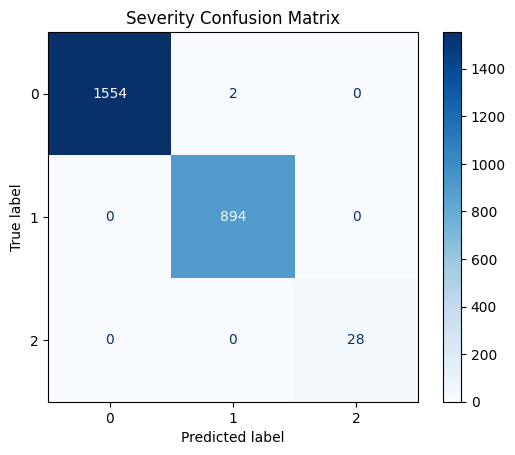

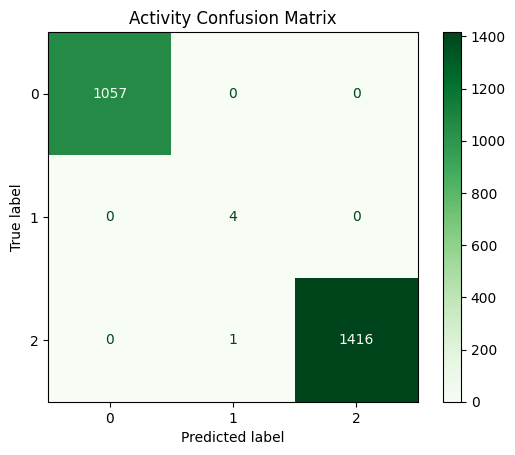

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_sev_true, y_sev_pred, cmap="Blues"
)
plt.title("Severity Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(
    y_act_true, y_act_pred, cmap="Greens"
)
plt.title("Activity Confusion Matrix")
plt.show()


In [16]:
!pip3 install -U scikit-learn

  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
